# Gold Miners Equity Alpha

In [1]:
import os
import numpy as np
import pandas as pd
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

# Getting Data

In [2]:
alpha_path = os.path.join(os.getcwd(), "data", "GoldMinersAlpha.parquet")
df_alpha   = (pd.read_parquet(
    path = alpha_path, engine = "pyarrow").
    reset_index().
    dropna())

In [3]:
path  = os.path.join(os.getcwd(), "data", "commod_px.parquet")
df_gc = (pd.read_parquet(
    path = path, engine = "pyarrow").
    query("security == 'GC1 Comdty'").
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    set_index("date")
    [["PX_LAST"]].
    sort_index().
    pct_change().
    rename(columns = {"PX_LAST": "gc_rtn"}))

# Single exogenous variable regression

In [4]:
def _get_resid(df: pd.DataFrame, q: int = 10) -> pd.DataFrame: 
    
    df_tmp = df.dropna().sort_index()
    df_out = (sm.OLS(
        endog = df_tmp.gc_rtn,
        exog  = sm.add_constant(df_tmp.alpha)).
        fit().
        resid.
        to_frame(name = "resid").
        assign(
            lag_resid = lambda x: x.resid.shift(),
            decile    = lambda x: pd.qcut(x = x.resid, q = q, labels = [i + 1 for i in range(q)]).shift()).
        merge(right = df, how = "inner", on = ["date"]))
    
    return df_out

df_ols = (df_gc.merge(
    right = df_alpha, how = "inner", on = ["date"]).
    set_index("date").
    groupby("group_var").
    apply(_get_resid, include_groups = False).
    reset_index().
    assign(signal_rtn = lambda x: -np.sign(x.lag_resid) * x.gc_rtn))

In [5]:
df_ols_rsk = (df_ols.pivot(
    index = "date", columns = "group_var", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.2, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(
        ticker = lambda x: x.group_var.str.split(" ").str[0],
        group  = lambda x: x.group_var.str.split(" ").str[1]).
    dropna())

Text(0.5, 0.98, 'Cumulative Returns for Trading Residuals of Regression using 10% Volatility Targeting\nFrom 1993-03-31 to 2026-01-12')

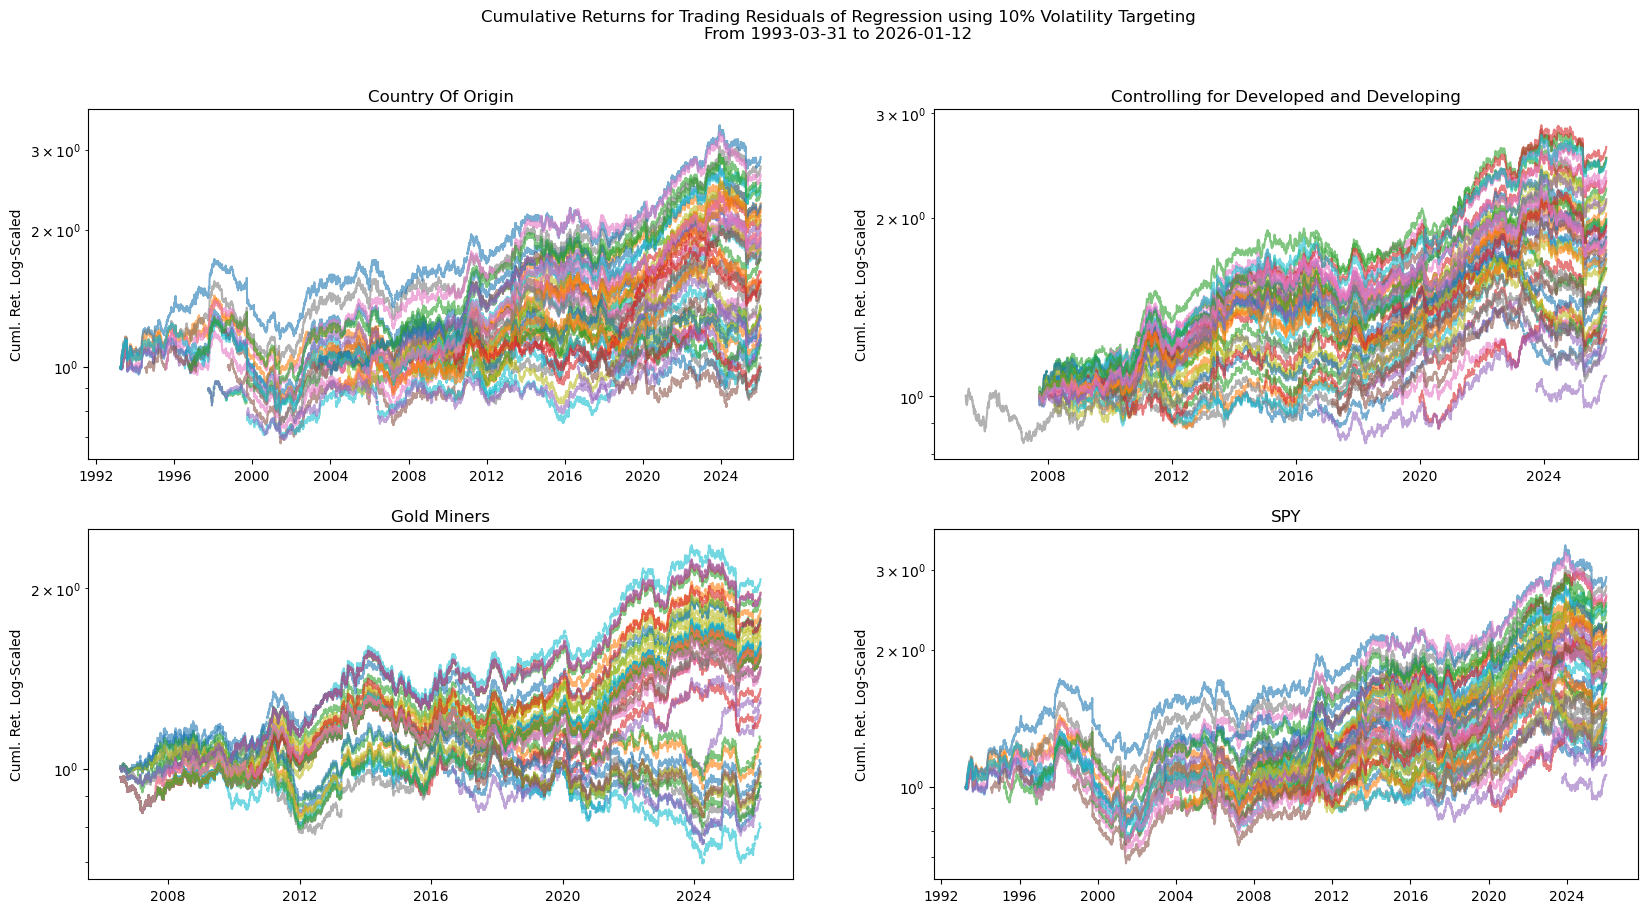

In [25]:
groups    = df_ols.group.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(groups) // 2, nrows = len(groups) // 2, figsize = (20,10))

renamer = {
    "country"           : "Country Of Origin",
    "country_type_group": "Controlling for Developed and Developing",
    "gdx"               : "Gold Miners",
    "spy"               : "SPY"}

for group, ax in zip(groups, axes.flatten()): 
    
    (df_ols_rsk.query(
        "group == @group").
        pivot(index = "date", columns = "ticker", values = "rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True, 
            alpha  = 0.6,
            legend = False,
            ax     = ax,
            title  = renamer[group],
            xlabel = "",
            ylabel = "Cuml. Ret. Log-Scaled"))

fig.suptitle("Cumulative Returns for Trading Residuals of Regression using 10% Volatility Targeting\nFrom {} to {}".format(
    df_ols_rsk.date.min(),
    df_ols_rsk.date.max()))

In [7]:
df_lag = (df_ols.pivot(
    index = "date", columns = "group_var", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(vol_target = "lagged"))

df_perf = (df_ols.pivot(
    index = "date", columns = "group_var", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(vol_target = "perfect"))

In [8]:
df_port = (pd.concat([
    df_lag, df_perf]).
    assign(
        rtn    = lambda x: np.where(np.abs(x.rtn) > 0.2, np.nan, x.rtn),
        ticker = lambda x: x.group_var.str.split(" ").str[0],
        group  = lambda x: x.group_var.str.split(" ").str[1]).
    dropna()
    [["date", "group", "rtn", "vol_target"]].
    groupby(["date", "group", "vol_target"]).
    agg("mean").
    reset_index())

In [9]:
replacer = {
        "gdx"               : "Gold Miners",
        "country"           : "Country\n(Origin)",
        "spy"               : "SPY",
        "country_type_group": "Developed/ing\nCountry"}

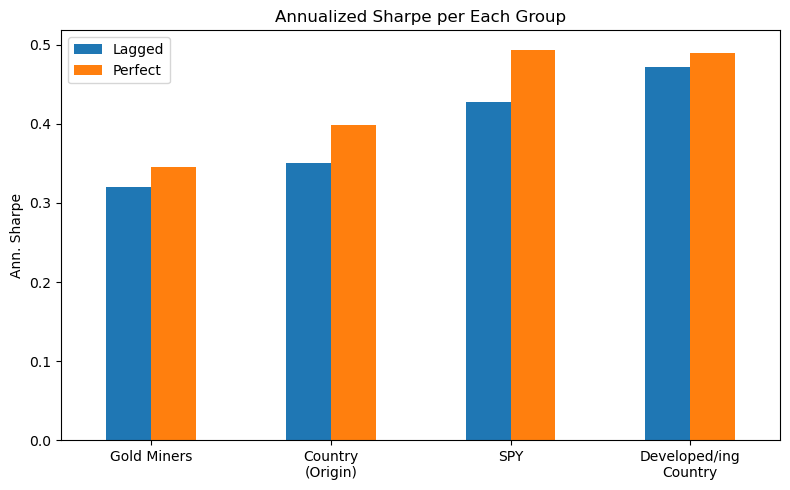

In [10]:
(df_port.drop(
    columns = ["date"]).
    groupby(["group", "vol_target"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(vol_target = lambda x: x.vol_target.str.capitalize()).
    rename(columns = {"vol_target": ""}).
    replace(replacer).
    pivot(index = "group", columns = "", values = "rtn").
    sort_values("Lagged").
    plot(
        figsize = (8,5),
        kind    = "bar",
        xlabel  = "",
        ylabel  = "Ann. Sharpe",
        title   = "Annualized Sharpe per Each Group",
        rot     = 0))

plt.tight_layout()

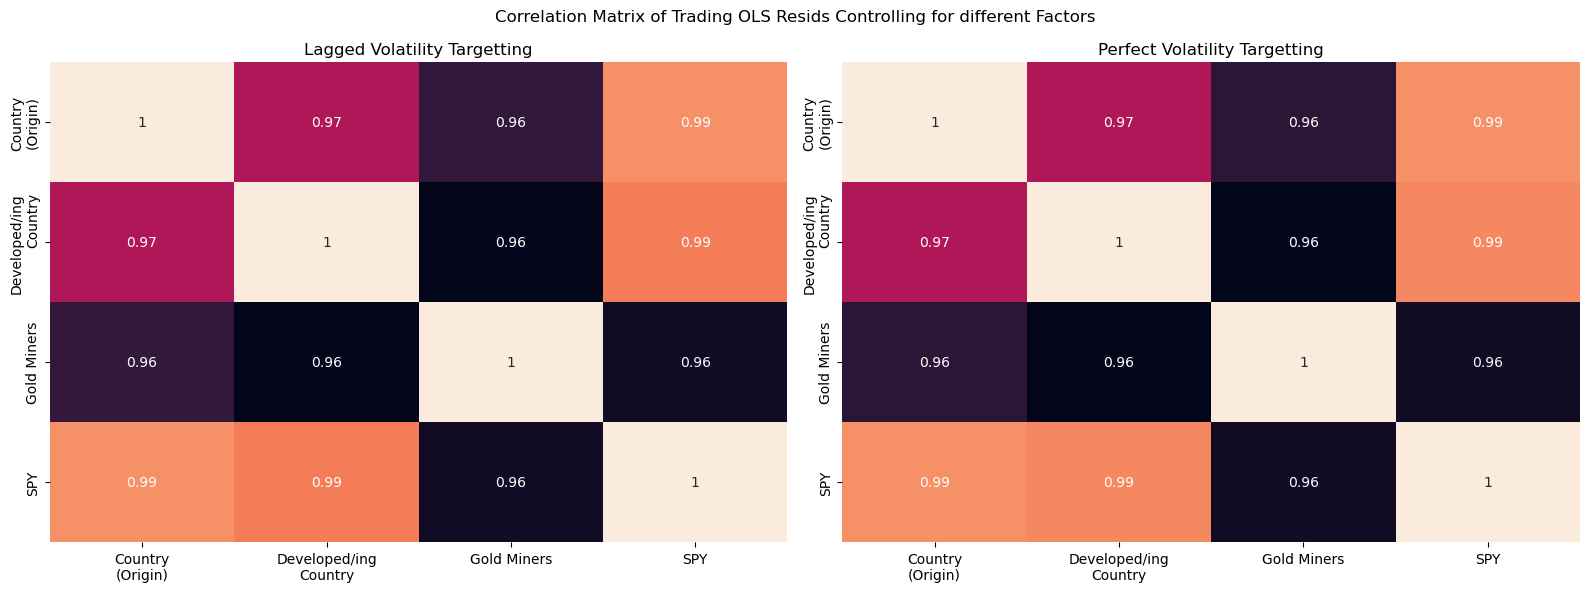

In [11]:
groups    = df_port.vol_target.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(groups), figsize = (16,6))

vol_renamer = {}

for group, ax in zip(groups, axes.flatten()): 

    df_corr = (df_port.query(
        "vol_target == @group").
        replace(replacer).
        pivot(index = "date", columns = "group", values = "rtn").
        corr().
        apply(lambda x: np.round(x,3)))

    sns.heatmap(
        ax    = ax,
        data  = df_corr,
        annot = True,
        cbar  = False)

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(group.capitalize() + " Volatility Targetting")

fig.suptitle("Correlation Matrix of Trading OLS Resids Controlling for different Factors")
plt.tight_layout()

# Trading Deciles of Single Exogenous Residuals

In [12]:
df_decile_sharpe = (df_ols[
    ["group_var", "decile", "gc_rtn"]].
    dropna().
    groupby(["group_var", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"gc_rtn": "sharpe"}))

In [13]:
df_tmp = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(group = lambda x: np.where(x.decile <= 2, "lgroup", "ugroup")))

In [14]:
df_scaler = (df_tmp.drop(
    columns = ["decile"]).
    groupby(["group_var", "group"]).
    agg("prod").
    assign(signal_scaler = lambda x: np.where(x.sharpe > 0, 1, 0)).
    drop(columns = ["sharpe"]).
    reset_index())

In [15]:
df_decile_rtn = (df_tmp.merge(
    right = df_scaler, how = "inner", on = ["group_var", "group"]).
    drop(columns = ["group"]).
    assign(signal = lambda x: np.sign(x.sharpe) * x.signal_scaler).
    merge(right = df_ols, how = "outer", on = ["group_var", "decile"]).
    assign(signal_rtn = lambda x: x.signal * x.gc_rtn))

In [16]:
df_wider = (df_decile_rtn.pivot(
    index = "date", columns = "group_var", values = "signal_rtn"))

In [17]:
df_lagged = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(vol_target = "lagged"))

df_perf = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(vol_target = "perfect"))

In [18]:
df_decile_rsk_rtn = (pd.concat([
    df_lagged, df_perf]).
    dropna().
    assign(
        rtn = lambda x: np.where(np.abs(x.rtn) > 0.1, np.nan, x.rtn),
        ticker = lambda x: x.group_var.str.split(" ").str[0],
        group  = lambda x: x.group_var.str.split(" ").str[1]))

In [19]:
df_decile_rsk_port = (df_decile_rsk_rtn[
    ["date", "vol_target", "group", "rtn"]].
    groupby(["date", "vol_target", "group"]).
    agg("mean").
    reset_index())

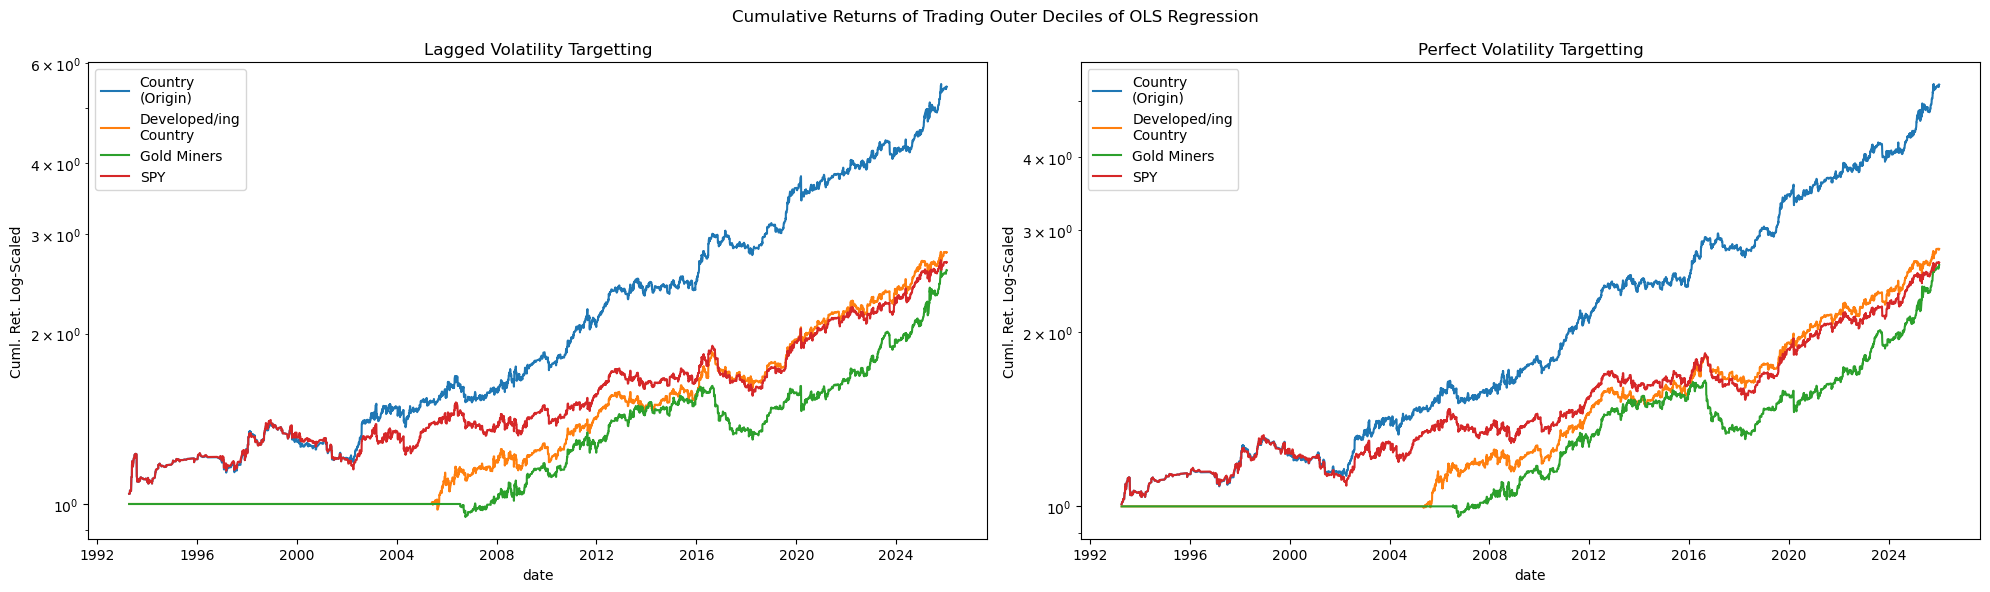

In [20]:
vol_targets = df_decile_rsk_port.vol_target.drop_duplicates().sort_values().to_list()
fig, axes   = plt.subplots(ncols = len(vol_targets), figsize = (20,6))

for vol_target, ax in zip(vol_targets, axes.flatten()):

    (df_decile_rsk_port.query(
        "vol_target == @vol_target").
        rename(columns = {"group": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        rename(columns = replacer).
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = vol_target.capitalize() + " Volatility Targetting"))

fig.suptitle("Cumulative Returns of Trading Outer Deciles of OLS Regression")
plt.tight_layout()

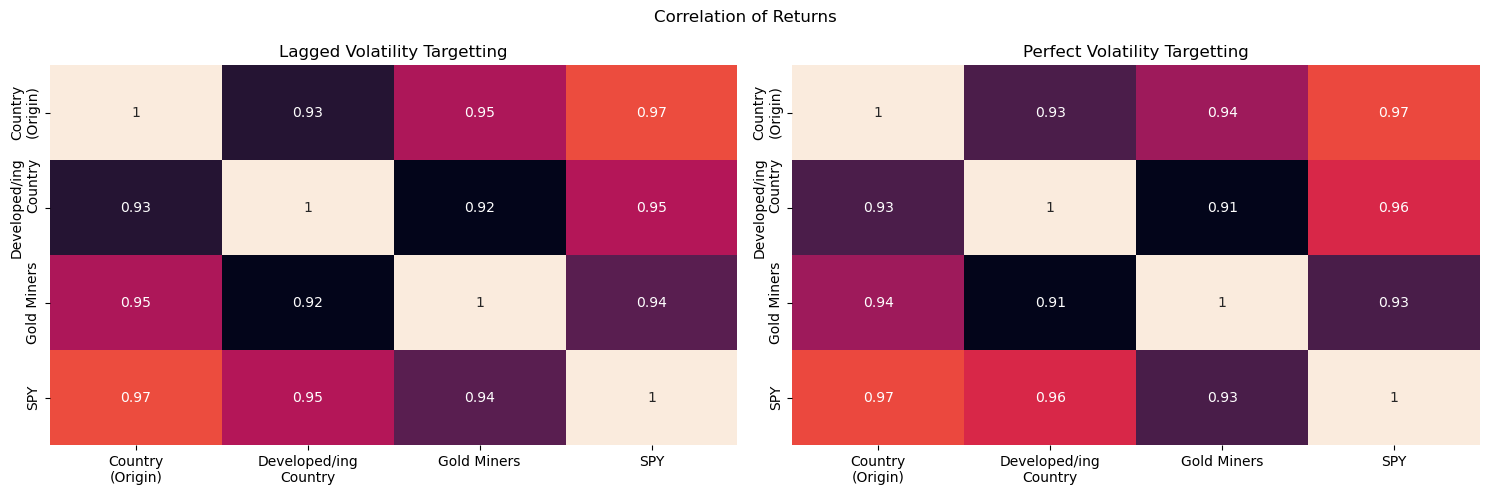

In [21]:
group_vars = df_decile_rsk_port.vol_target.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (15,5))

for group_var, ax in zip(group_vars, axes.flatten()): 

    df_corr = (df_decile_rsk_port.query(
        "vol_target == @group_var").
        pivot(index = "date", columns = "group", values = "rtn").
        rename(columns = replacer).
        corr())

    sns.heatmap(
        ax    = ax,
        data  = df_corr,
        annot = True,
        cbar  = False)

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(group_var.capitalize() + " Volatility Targetting")

fig.suptitle("Correlation of Returns")
plt.tight_layout()

In [22]:
df_decile_sharpe = (df_decile_rsk_port.rename(
    columns = {"rtn": "raw_val"}).
    assign(adj_val = lambda x: np.where(x.raw_val == 0, np.nan, x.raw_val)).
    melt(id_vars = ["date", "vol_target", "group"]).
    dropna().
    drop(columns =  ["date"]).
    groupby(["vol_target", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index())

In [23]:
replacer = {
        "gdx"               : "Gold Miners",
        "country"           : "Country (Origin)",
        "spy"               : "SPY",
        "country_type_group": "Developed/ing Country"}

In [24]:
(df_decile_sharpe.replace(
    replacer).
    assign(vol_target = lambda x: x.vol_target.str.capitalize()).
    rename(columns = {
        "variable"  : "",
        "vol_target": "Vol. Target"}).
    pivot(index = ["group"], columns = ["Vol. Target", ""], values = "value").
    rename(columns = {
        "adj_val": "Adj Val",
        "raw_val": "Raw Val"}).
    apply(lambda x: np.round(x,3)))

Vol. Target            Lagged         Perfect        
                      Adj Val Raw Val Adj Val Raw Val
group                                                
Country (Origin)        1.050   1.023   1.152   1.121
Developed/ing Country   1.131   1.108   1.235   1.210
Gold Miners             1.033   0.996   1.116   1.077
SPY                     0.741   0.725   0.814   0.797

# Multi-Exogenous Variable Regression

In [27]:
path = r"data/MultiGoldMinersAlpha.parquet"

In [31]:
df_alpha = (pd.read_parquet(
    path = path, engine = "pyarrow")
    [["endog_ticker", "date", "alpha"]].
    dropna())

In [50]:
def _get_resid(df: pd.DataFrame, q: int = 10) -> pd.DataFrame: 

    df_out = (sm.OLS(
        endog = df.gc_rtn,
        exog  = sm.add_constant(df.alpha)).
        fit().
        resid.
        to_frame(name = "resid").
        assign(
            lag_resid = lambda x: x.resid.shift(),
            decile    = lambda x: pd.qcut(x = x.resid, q = 10, labels = [i + 1 for i in range(10)]).shift()).
        merge(right = df, how = "inner", on = ["date"]))

    return df_out

df_resid = (df_gc.merge(
    right = df_alpha, how = "inner", on = ["date"]).
    set_index("date").
    groupby("endog_ticker").
    apply(_get_resid, include_groups = False).
    reset_index().
    assign(signal_rtn = lambda x: -np.sign(x.lag_resid) * x.gc_rtn))

In [53]:
df_wider = (df_resid.pivot(
    index = "date", columns = "endog_ticker", values = "signal_rtn"))

In [58]:
df_lagged = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(vol_target = "lagged"))

df_perf = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(vol_target = "perfect"))

In [60]:
df_combined = (pd.concat([df_lagged, df_perf]))

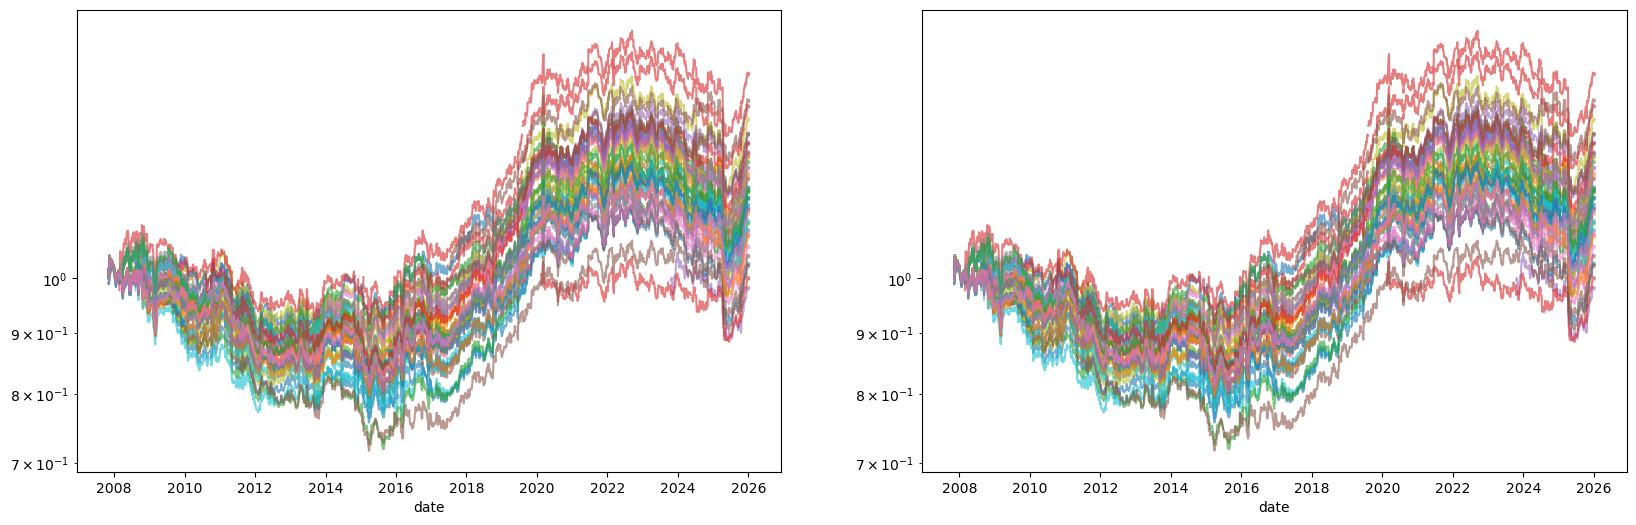

In [70]:
group_vars = df_combined.vol_target.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,6))

for group_var, ax in zip(group_vars, axes.flatten()):

    (df_combined.query(
        "vol_target == @vol_target").
        pivot(index = "date", columns = "endog_ticker", values = "rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True, 
            alpha  = 0.6, 
            legend = False))

In [77]:
df_decile_sharpe = (df_resid[
    ["endog_ticker", "decile", "gc_rtn"]].
    groupby(["endog_ticker", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index())

In [82]:
df_decile_tmp = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(group = lambda x: np.where(x.decile <= 2, "lgroup", "ugroup")))

In [173]:
df_decile_rtn = (df_decile_tmp.drop(
    columns = ["decile"]).
    groupby(["endog_ticker", "group"]).
    agg("prod").
    assign(sig_scaler = lambda x: np.where(x.gc_rtn > 0, 1, np.nan)).
    reset_index().
    drop(columns = ["gc_rtn"]).
    merge(right = df_decile_tmp, how = "outer", on = ["endog_ticker", "group"]).
    rename(columns = {"gc_rtn": "sharpe"}).
    merge(right = df_resid, how = "outer", on = ["endog_ticker", "decile"]).
    assign(signal_rtn = lambda x: np.sign(x.sig_scaler  * x.sharpe) * x.gc_rtn))